# Scenario Comparison Analysis

In [ ]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [ ]:
# Load the three networks
n1 = pypsa.Network("../results/germany_base_windy/postnetworks/elec_s_450_ec_lcopt_Co2L-24H.nc")
n2 = pypsa.Network("../results/germany_base_notwindy/postnetworks/elec_s_450_ec_lcopt_Co2L-24H.nc")
n3 = pypsa.Network("../results/germany_base_windvariability/postnetworks/elec_s_450_ec_lcopt_Co2L-24H.nc")

# Rename columns for better legend
for n in [n1, n2, n3]:
    n.loads_t.p_set.columns = ["Load"]
    n.generators_t.p_max_pu.columns = n.generators.carrier + " " + n.generators.bus
    n.storage_units_t.p_max_pu.columns = n.storage_units.carrier + " " + n.storage_units.bus

# Load solved networks

In [ ]:
# Group and sum generator power by carrier
p_by_carrier1 = n1.generators_t.p.groupby(n1.generators.carrier, axis=1).sum()
p_by_carrier2 = n2.generators_t.p.groupby(n2.generators.carrier, axis=1).sum()
p_by_carrier3 = n3.generators_t.p.groupby(n3.generators.carrier, axis=1).sum()

# Order columns for plotting
order = ["hydro", "onwind", "solar", "ror", "geothermal", "biomass", "nuclear", "oil", "coal", "lignite", "OCGT", "CCGT"]
p_by_carrier1 = p_by_carrier1.reindex(columns=order)
p_by_carrier2 = p_by_carrier2.reindex(columns=order)
p_by_carrier3 = p_by_carrier3.reindex(columns=order)

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [ ]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot for n1
p_by_carrier1.plot(ax=axes[0], kind="area", lw=0, title="Windy")
n1.loads_t.p_set.plot(ax=axes[0], c="k", ls="-", lw=2)
axes[0].legend(loc=(1.05, 0))
axes[0].set_ylabel("Power [MW]")

# Plot for n2
p_by_carrier2.plot(ax=axes[1], kind="area", lw=0, title="Not Windy")
n2.loads_t.p_set.plot(ax=axes[1], c="k", ls="-", lw=2)
axes[1].legend(loc=(1.05, 0))
axes[1].set_ylabel("Power [MW]")

# Plot for n3
p_by_carrier3.plot(ax=axes[2], kind="area", lw=0, title="Wind Variability")
n3.loads_t.p_set.plot(ax=axes[2], c="k", ls="-", lw=2)
axes[2].legend(loc=(1.05, 0))
axes[2].set_ylabel("Power [MW]")

plt.tight_layout()
plt.show()

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


## 4. Comparison Plots

### 4.1 Grid Congestion and Curtailment

In [ ]:
print("System cost in windy case: ", n1.objective)
print("System cost in not windy case: ", n2.objective)
print("System cost in wind variability case: ", n3.objective)

Line capacities differ between the two networks.


##### Line Loading Comparison

##### Offshore Wind Curtailment

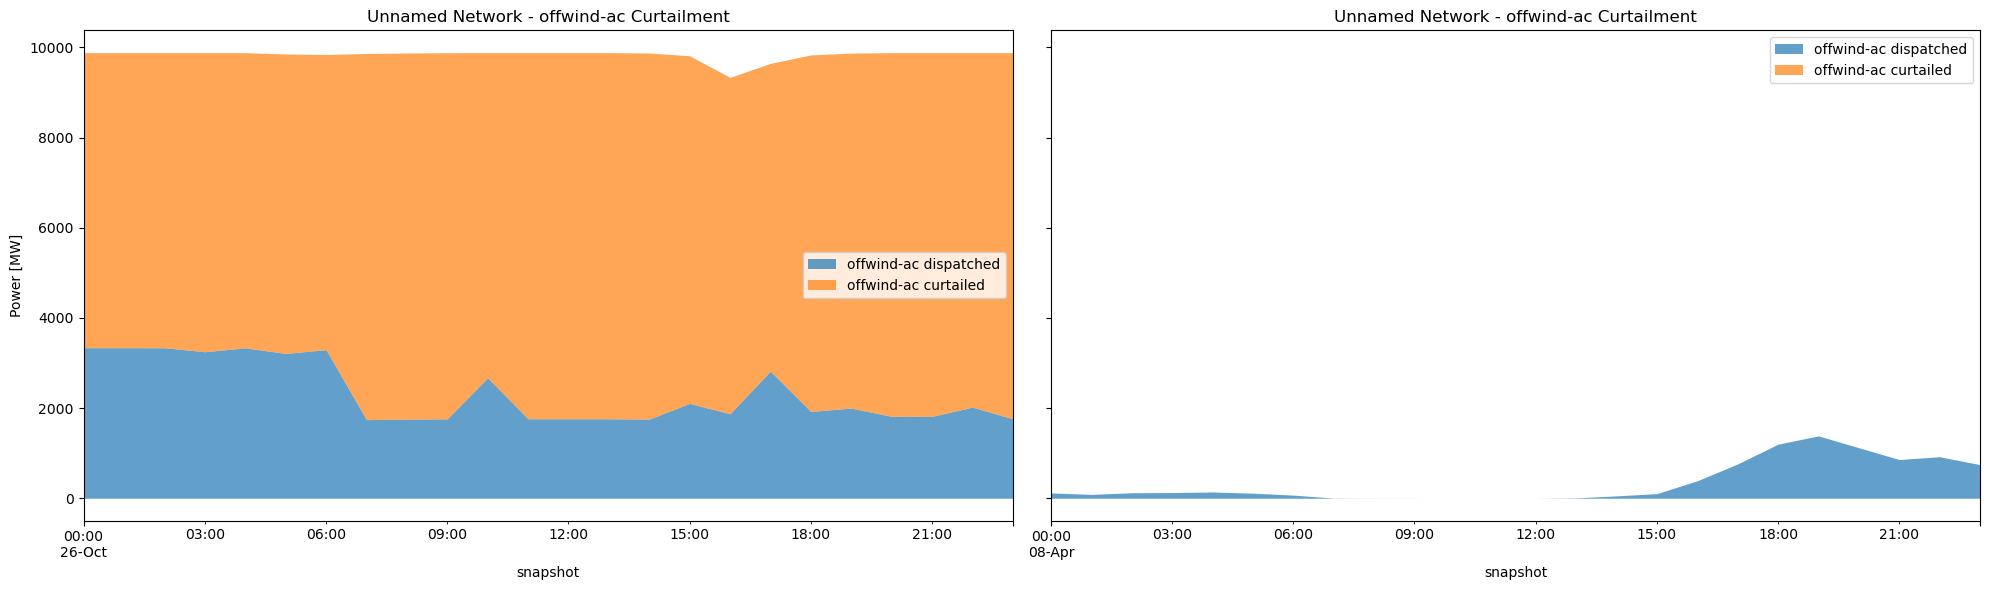

In [ ]:
# Calculate average line loading
line_loading_1 = n1.lines_t.p0.abs().mean() / n1.lines.s_nom
line_loading_2 = n2.lines_t.p0.abs().mean() / n2.lines.s_nom
line_loading_3 = n3.lines_t.p0.abs().mean() / n3.lines.s_nom

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Windy': line_loading_1,
    'Not Windy': line_loading_2,
    'Wind Variability': line_loading_3
})

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
df.plot(kind='bar', ax=ax)
ax.set_xlabel('Lines')
ax.set_ylabel('Average Loading')
ax.set_title('Average Line Loading Comparison')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

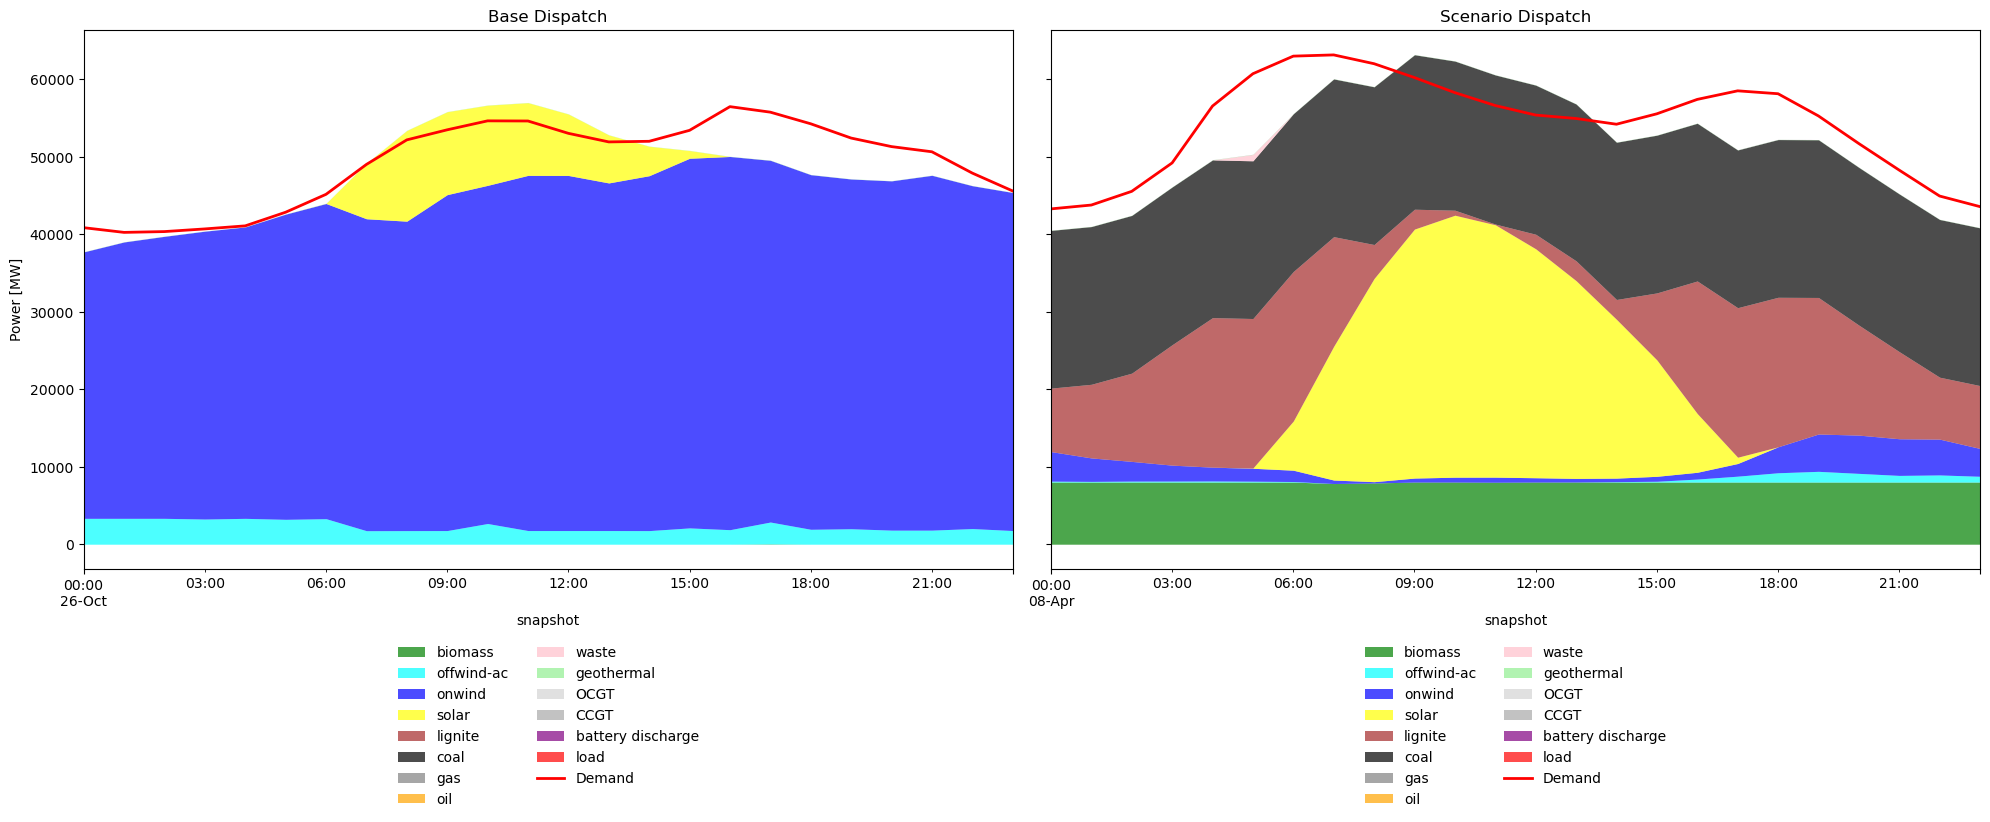

In [ ]:
# Plotting the prices for each network
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Plot for n1
axes[0].plot(n1.buses_t.marginal_price.iloc[:,:5])
axes[0].set_title('Windy')
axes[0].set_ylabel('Price [€/MWh]')
axes[0].legend(n1.buses_t.marginal_price.columns[:5], loc='upper left')

# Plot for n2
axes[1].plot(n2.buses_t.marginal_price.iloc[:,:5])
axes[1].set_title('Not Windy')
axes[1].set_ylabel('Price [€/MWh]')
axes[1].legend(n2.buses_t.marginal_price.columns[:5], loc='upper left')

# Plot for n3
axes[2].plot(n3.buses_t.marginal_price.iloc[:,:5])
axes[2].set_title('Wind Variability')
axes[2].set_ylabel('Price [€/MWh]')
axes[2].legend(n3.buses_t.marginal_price.columns[:5], loc='upper left')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

##### Total Energy Production by Carrier

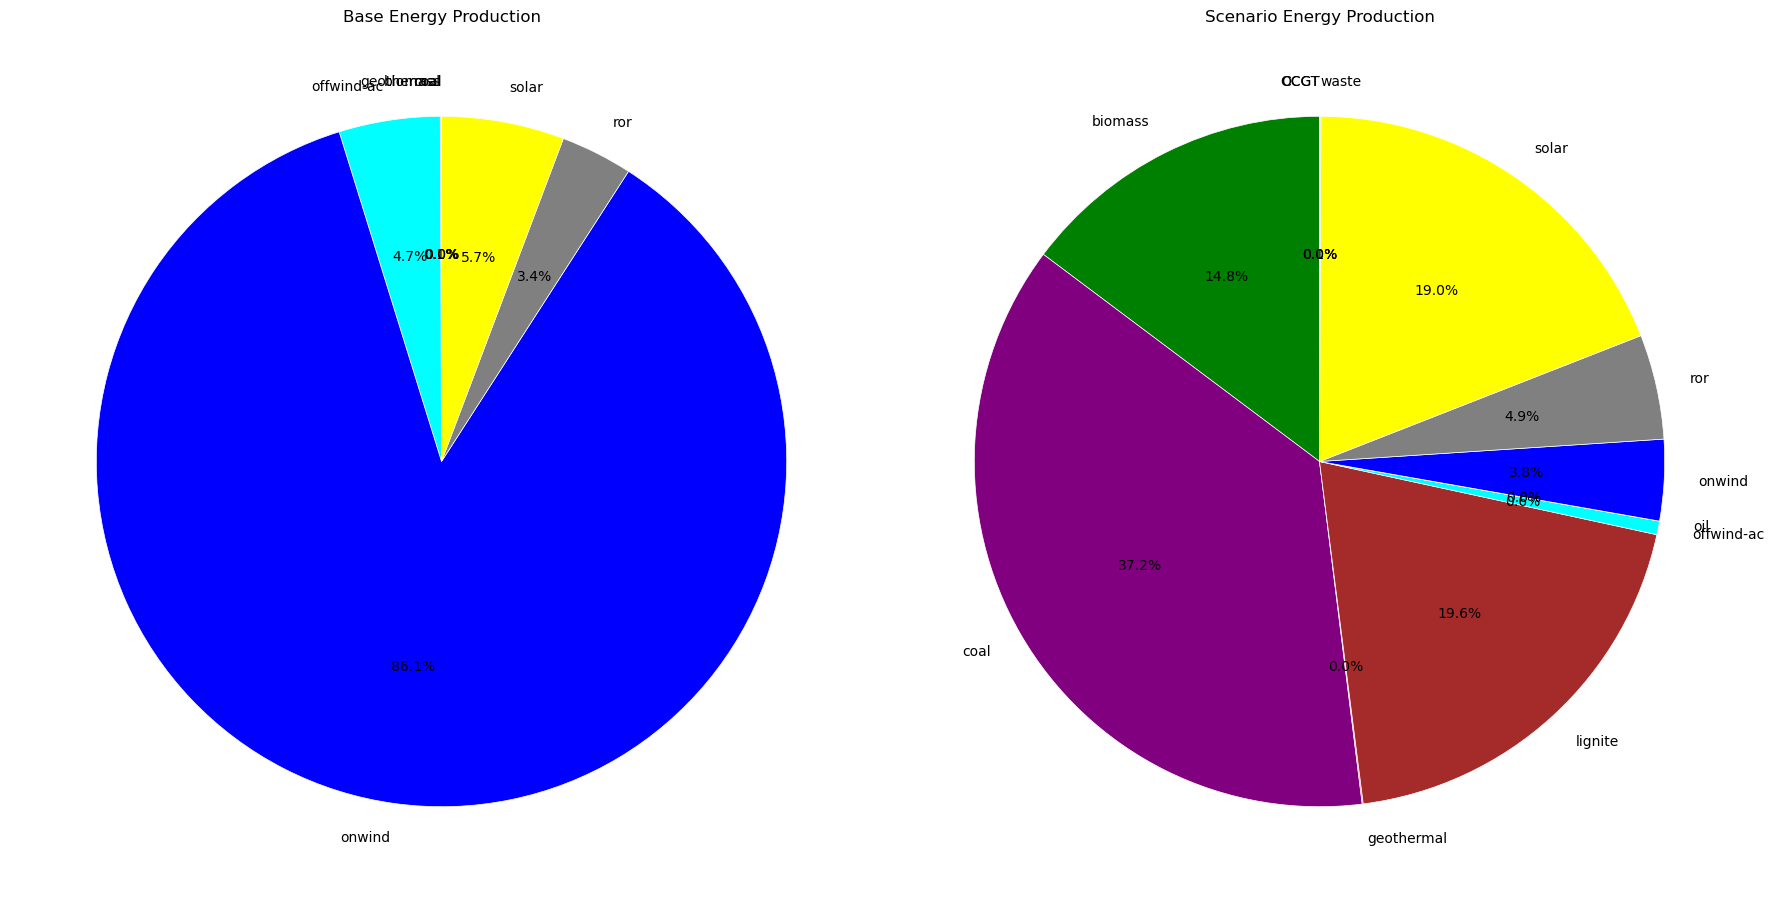

In [ ]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot for n1
bus_sizes1 = n1.buses.x**2 + n1.buses.y**2
n1.plot(bus_sizes=bus_sizes1*0, bus_colors=n1.buses_t.marginal_price.mean(), ax=axes[0])
axes[0].set_title("Average marginal prices for windy case")

# Plot for n2
bus_sizes2 = n2.buses.x**2 + n2.buses.y**2
n2.plot(bus_sizes=bus_sizes2*0, bus_colors=n2.buses_t.marginal_price.mean(), ax=axes[1])
axes[1].set_title("Average marginal prices for not windy case")

# Plot for n3
bus_sizes3 = n3.buses.x**2 + n3.buses.y**2
n3.plot(bus_sizes=bus_sizes3*0, bus_colors=n3.buses_t.marginal_price.mean(), ax=axes[2])
axes[2].set_title("Average marginal prices for wind variability case")

plt.tight_layout()
plt.show()

### 4.3 Energy Balance


##### Unserved Energy Analysis


In [ ]:
# Calculate generator statistics for each network
def get_generator_stats(n):
    p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()
    
    # Capacity factor
    capacity_factor = p_by_carrier / n.generators.groupby("carrier").p_nom.sum()
    
    # Curtailment
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_curtailed = p_available.groupby(n.generators.carrier, axis=1).sum() - p_by_carrier
    curtailment = p_curtailed.sum() / p_available.groupby(n.generators.carrier, axis=1).sum().sum()
    
    return p_by_carrier.sum(), capacity_factor.mean(), curtailment

p_sum1, cf1, curtailment1 = get_generator_stats(n1)
p_sum2, cf2, curtailment2 = get_generator_stats(n2)
p_sum3, cf3, curtailment3 = get_generator_stats(n3)

# Create a DataFrame for comparison
stats_df = pd.DataFrame({
    'Production Windy [MWh]': p_sum1,
    'Production Not Windy [MWh]': p_sum2,
    'Production Wind Variability [MWh]': p_sum3,
    'Capacity Factor Windy': cf1,
    'Capacity Factor Not Windy': cf2,
    'Capacity Factor Wind Variability': cf3,
    'Curtailment Windy': curtailment1,
    'Curtailment Not Windy': curtailment2,
    'Curtailment Wind Variability': curtailment3
})

stats_df.sort_index(axis=1)

NameError: name 'n_scenario' is not defined

In [ ]:
# Plotting production
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
p_sum1.plot(kind="bar", ax=axes[0], title="Total Production Windy")
p_sum2.plot(kind="bar", ax=axes[1], title="Total Production Not Windy")
p_sum3.plot(kind="bar", ax=axes[2], title="Total Production Wind Variability")
axes[0].set_ylabel("Production [MWh]")
plt.tight_layout()
plt.show()

# Plotting capacity factor
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
cf1.plot(kind="bar", ax=axes[0], title="Capacity Factor Windy")
cf2.plot(kind="bar", ax=axes[1], title="Capacity Factor Not Windy")
cf3.plot(kind="bar", ax=axes[2], title="Capacity Factor Wind Variability")
axes[0].set_ylabel("Capacity Factor")
plt.tight_layout()
plt.show()

# Plotting curtailment
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
curtailment1.plot(kind="bar", ax=axes[0], title="Curtailment Windy")
curtailment2.plot(kind="bar", ax=axes[1], title="Curtailment Not Windy")
curtailment3.plot(kind="bar", ax=axes[2], title="Curtailment Wind Variability")
axes[0].set_ylabel("Curtailment")
plt.tight_layout()
plt.show()

--- Full Bus Balance Check (Scenario) ---
Total absolute residual: 0.00 MWh
Net residual over horizon: -0.00 MWh
Peak hourly residual: 0.00 MW
Residual as share of total demand: 0.0000%
----------------------------------------------------
The remaining imbalance is just numerical noise.

Top buses by net residual over the horizon:
DE0 0     -7.680967e-11
DE0 126    6.144418e-11
DE0 181   -5.456968e-11
DE0 117    5.377743e-11
DE0 250   -5.002221e-11
DE0 358   -4.471801e-11
DE0 255    3.745981e-11
DE0 135   -3.487033e-11
DE0 8     -3.337523e-11
DE0 203    3.228706e-11
dtype: float64
